# Configuración del Entorno e Importaciones

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import warnings
import time
import json
import os

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve, average_precision_score, 
                             precision_recall_curve, f1_score, recall_score, 
                             accuracy_score)

from mealpy import FloatVar, GWO, MFO
from scipy.stats import wilcoxon, shapiro, t as t_dist

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="paper")

# ============================================================
# REPRODUCIBILIDAD GLOBAL
# ============================================================
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# Directorio de salida para figuras y resultados
OUTPUT_DIR = "resultados_gwo_mfo"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"XGBoost version: {xgb.__version__}")
print(f"Directorio de salida: {OUTPUT_DIR}")

XGBoost version: 3.3.0
Directorio de salida: resultados_gwo_mfo


# Carga y Preprocesamiento de Datos

In [6]:
df = pd.read_csv('../../../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'target'}, inplace=True)

if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dimensiones del dataset: {df.shape}")
print(f"Distribución de clases:\n{df['target'].value_counts()}")
print(f"Prevalencia clase positiva: {df['target'].mean():.4f}")

Dimensiones del dataset: (30000, 24)
Distribución de clases:
target
0    23364
1     6636
Name: count, dtype: int64
Prevalencia clase positiva: 0.2212


# División Train/Test y Cálculo de Scale Pos Weight

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=GLOBAL_SEED, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Clase 0 (train): {neg} | Clase 1 (train): {pos}")
print(f"Scale Pos Weight: {base_scale_pos_weight:.4f}")

Train: (24000, 23) | Test: (6000, 23)
Clase 0 (train): 18691 | Clase 1 (train): 5309
Scale Pos Weight: 3.5206


# Función de Evaluación Completa (con TP/FP/TN/FN)

In [8]:
def evaluate_model(y_true, y_pred, y_prob, model_name="Modelo"):
    """Evalúa un modelo y retorna todas las métricas + matriz de confusión."""
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"--- {model_name} ---")
    print(f"PR-AUC: {pr_auc:.4f} | ROC-AUC: {roc_auc:.4f} | "
          f"F1: {f1:.4f} | Recall: {rec:.4f} | Acc: {acc:.4f}")
    print(f"TP={tp} | FP={fp} | TN={tn} | FN={fn}")
    
    return {
        "pr_auc": pr_auc, "roc_auc": roc_auc, "f1": f1,
        "recall": rec, "accuracy": acc,
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn)
    }

# Entrenamiento del Modelo Base XGBoost

In [9]:
t0 = time.time()
model_base = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=base_scale_pos_weight,
    tree_method='hist', device='cuda', eval_metric='aucpr',
    random_state=GLOBAL_SEED, verbosity=0
)
model_base.fit(X_train, y_train, verbose=False)
t_base = time.time() - t0

y_pred_base = model_base.predict(X_test)
y_prob_base = model_base.predict_proba(X_test)[:, 1]
metrics_base = evaluate_model(y_test, y_pred_base, y_prob_base, "MODELO BASE")
print(f"⏱️ Tiempo entrenamiento base: {t_base:.1f}s")

--- MODELO BASE ---
PR-AUC: 0.5459 | ROC-AUC: 0.7687 | F1: 0.5307 | Recall: 0.5870 | Acc: 0.7703
TP=779 | FP=830 | TN=3843 | FN=548
⏱️ Tiempo entrenamiento base: 2.0s


# Visualización del Modelo Base

💾 Figura guardada: resultados_gwo_mfo/eval_BASE.png


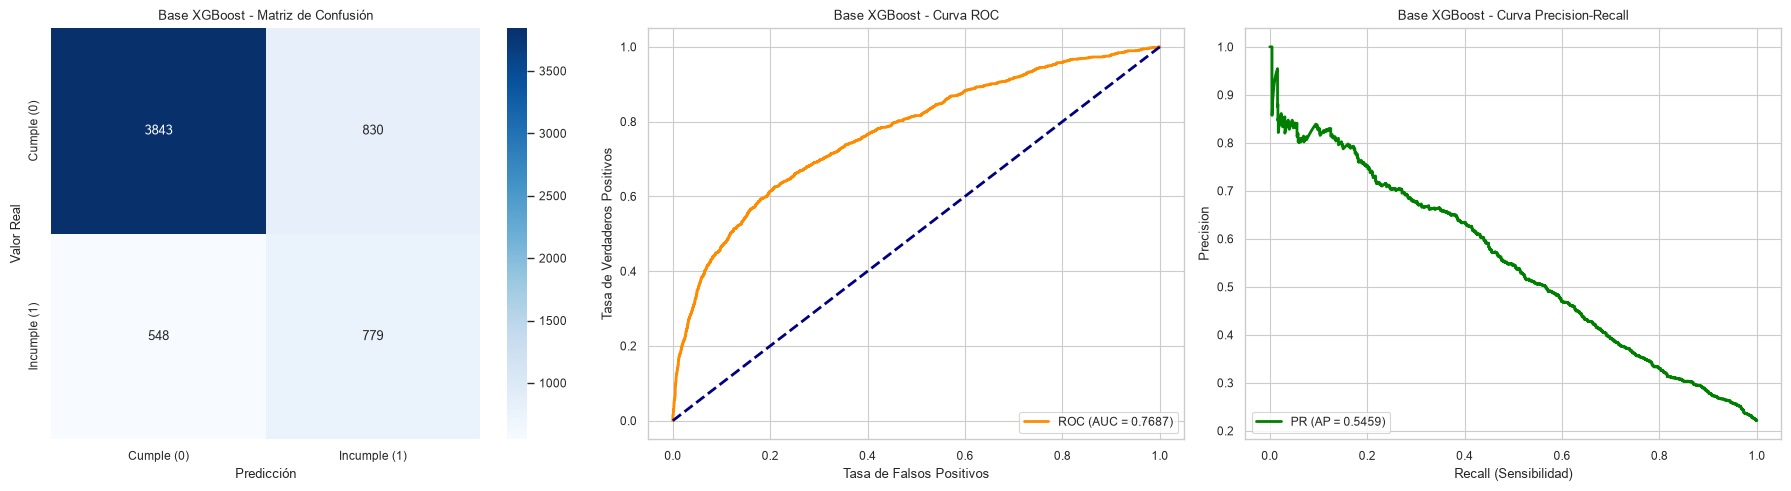

In [10]:
def plot_model_evaluation(y_true, y_pred, y_prob, title_prefix="Modelo", 
                          save_path=None):
    """Genera matriz de confusión, ROC y PR. Opcionalmente guarda."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Cumple (0)', 'Incumple (1)'],
                yticklabels=['Cumple (0)', 'Incumple (1)'])
    axes[0].set_title(f'{title_prefix} - Matriz de Confusión')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
                 label=f'ROC (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'{title_prefix} - Curva ROC')
    axes[1].legend(loc="lower right")

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    axes[2].plot(recall, precision, color='green', lw=2, 
                 label=f'PR (AP = {pr_auc:.4f})')
    axes[2].set_xlabel('Recall (Sensibilidad)')
    axes[2].set_ylabel('Precision')
    axes[2].set_title(f'{title_prefix} - Curva Precision-Recall')
    axes[2].legend(loc="lower left")
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"💾 Figura guardada: {save_path}")
    plt.show()

plot_model_evaluation(y_test, y_pred_base, y_prob_base, "Base XGBoost",
                      save_path=f"{OUTPUT_DIR}/eval_BASE.png")

# Función Objetivo y Límites para GWO

In [11]:
LB = [100, 3, 0.01, 0.6, 0.6, 2.0]
UB = [600, 10, 0.15, 1.0, 1.0, 5.0]

MIN_RECALL_THRESHOLD = 0.55
PENALTY_LAMBDA = 0.8  # ← λ = 0.8 (NO 10)

def extract_params(solution):
    """Extrae hiperparámetros con redondeo correcto (P-1)."""
    params = {
        "n_estimators": int(round(solution[0])),
        "max_depth": int(round(solution[1])),
        "learning_rate": float(solution[2]),
        "subsample": float(solution[3]),
        "colsample_bytree": float(solution[4]),
        "scale_pos_weight": float(solution[5])
    }
    # P-7: Verificación de rango
    for i, (key, lb, ub) in enumerate(zip(
        ["n_estimators","max_depth","learning_rate",
         "subsample","colsample_bytree","scale_pos_weight"], LB, UB)):
        val = params[key]
        if not (lb <= val <= ub):
            print(f"⚠️ {key}={val} fuera de [{lb},{ub}], clampeando.")
            params[key] = max(lb, min(ub, val))
    return params

def make_objective(seed_val):
    """Crea función objetivo con semilla específica (P-8: fuera del loop)."""
    def obj(solution):
        params = extract_params(solution)
        params.update({
            "tree_method": 'hist', "device": 'cuda', "eval_metric": 'aucpr',
            "early_stopping_rounds": 30, "random_state": seed_val, "verbosity": 0
        })
        
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed_val)
        scores = []
        
        for train_idx, val_idx in skf.split(X_train, y_train):
            X_tr = X_train.iloc[train_idx]
            X_val = X_train.iloc[val_idx]
            y_tr = y_train.iloc[train_idx]
            y_val = y_train.iloc[val_idx]
            
            m = xgb.XGBClassifier(**params)
            m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            
            y_p = m.predict(X_val)
            y_p_prob = m.predict_proba(X_val)[:, 1]
            
            pr_auc = average_precision_score(y_val, y_p_prob)
            f1 = f1_score(y_val, y_p)
            rec = recall_score(y_val, y_p)
            
            combined = np.sqrt(pr_auc * f1)  # Media geométrica
            penalty = max(0.0, (MIN_RECALL_THRESHOLD - rec) * PENALTY_LAMBDA)
            scores.append((1.0 - combined) + penalty)
            
        return np.mean(scores)
    return obj

# Función objetivo principal (semilla fija = GLOBAL_SEED)
objective_function_gwo = make_objective(GLOBAL_SEED)

problem_dict = {
    "obj_func": objective_function_gwo,
    "bounds": FloatVar(lb=LB, ub=UB, name="xgb_hyperparams"),
    "minmax": "min",
}

# Optimización GWO (15 Iteraciones)

In [12]:
np.random.seed(GLOBAL_SEED)  # P-9: Semilla explícita para Mealpy
t0 = time.time()
gwo_15_model = GWO.OriginalGWO(epoch=15, pop_size=20)
gwo_15_best = gwo_15_model.solve(problem_dict)
t_gwo15 = time.time() - t0

print(f"✅ GWO-15 completado en {t_gwo15:.1f}s")
print(f"Mejor fitness: {gwo_15_best.target.fitness:.4f}")
print(f"OFEs reales: 20 × 15 × 3 = {20*15*3}")

best_params_15 = extract_params(gwo_15_best.solution)
print(f"Mejores hiperparámetros: {best_params_15}")

2026/07/24 09:50:35 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=15, pop_size=20)
2026/07/24 09:51:15 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44875970855204095, Global best: 0.44875970855204095, Runtime: 19.15198 seconds
2026/07/24 09:51:32 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44875970855204095, Global best: 0.44875970855204095, Runtime: 16.74289 seconds
2026/07/24 09:51:52 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44834268725271004, Global best: 0.44834268725271004, Runtime: 20.66981 seconds
2026/07/24 09:52:07 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.44834268725271004, Global best: 0.44834268725271004, Runtime: 14.23390 seconds
2026/07/24 09:52:22 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44653309578971934, Global best: 0.44653309578971

✅ GWO-15 completado en 259.1s
Mejor fitness: 0.4450
OFEs reales: 20 × 15 × 3 = 900
Mejores hiperparámetros: {'n_estimators': 423, 'max_depth': 5, 'learning_rate': 0.07205576345693265, 'subsample': 0.7127759818003443, 'colsample_bytree': 0.7489969263867776, 'scale_pos_weight': 3.0507117077941808}


# Entrenamiento Final GWO (15 Iteraciones)

--- GWO (15 Iter) ---
PR-AUC: 0.5467 | ROC-AUC: 0.7698 | F1: 0.5283 | Recall: 0.5667 | Acc: 0.7762
TP=752 | FP=768 | TN=3905 | FN=575
💾 Figura guardada: resultados_gwo_mfo/eval_GWO_15.png


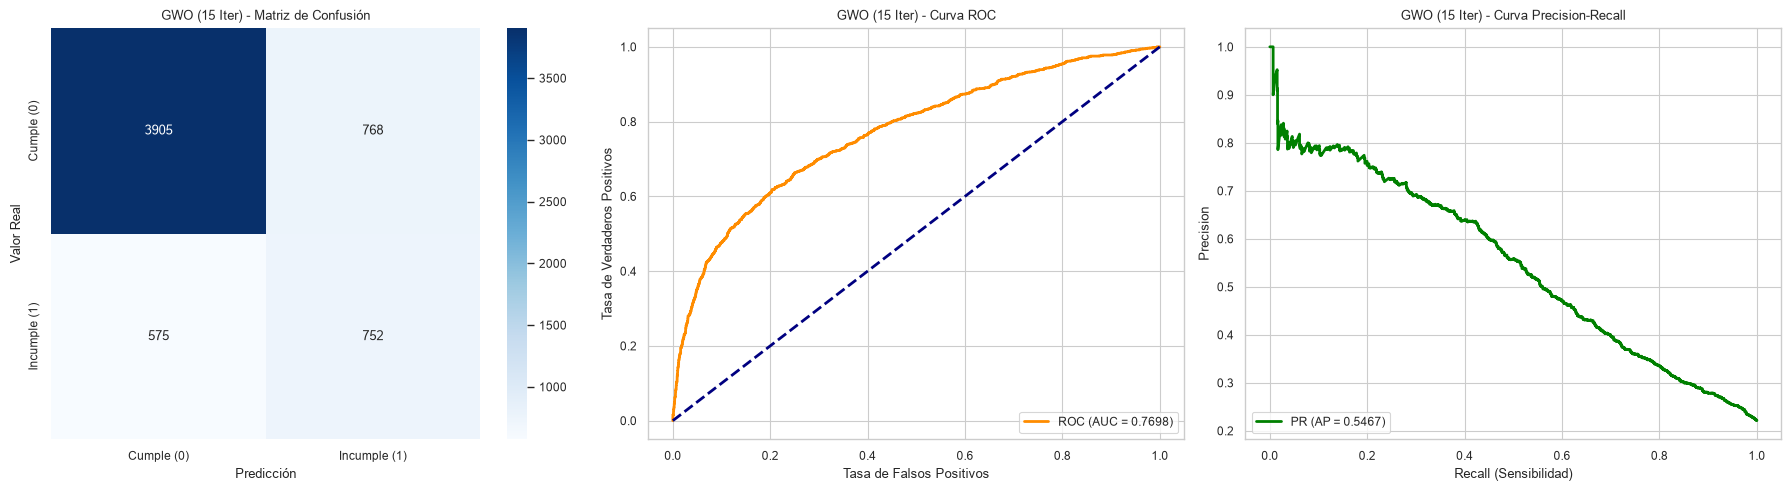

In [13]:
model_gwo_15 = xgb.XGBClassifier(
    **best_params_15, tree_method='hist', device='cuda',
    eval_metric='aucpr', random_state=GLOBAL_SEED, verbosity=0
)
model_gwo_15.fit(X_train, y_train, verbose=False)
        
y_pred_gwo_15 = model_gwo_15.predict(X_test)
y_prob_gwo_15 = model_gwo_15.predict_proba(X_test)[:, 1]
metrics_gwo_15 = evaluate_model(y_test, y_pred_gwo_15, y_prob_gwo_15, "GWO (15 Iter)")

plot_model_evaluation(y_test, y_pred_gwo_15, y_prob_gwo_15, "GWO (15 Iter)",
                      save_path=f"{OUTPUT_DIR}/eval_GWO_15.png")

# Optimización GWO (30 Iteraciones)

In [14]:
np.random.seed(GLOBAL_SEED)
t0 = time.time()
gwo_30_model = GWO.OriginalGWO(epoch=30, pop_size=20)
gwo_30_best = gwo_30_model.solve(problem_dict)
t_gwo30 = time.time() - t0

print(f"✅ GWO-30 completado en {t_gwo30:.1f}s")
print(f"Mejor fitness: {gwo_30_best.target.fitness:.4f}")
print(f"OFEs reales: 30 × 20 × 3 = {30*20*3}")

best_params_30 = extract_params(gwo_30_best.solution)
print(f"Mejores hiperparámetros: {best_params_30}")

2026/07/24 09:54:56 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=30, pop_size=20)
2026/07/24 09:55:35 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.4469402517858893, Global best: 0.4469402517858893, Runtime: 20.55061 seconds
2026/07/24 09:56:03 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4469402517858893, Global best: 0.4469402517858893, Runtime: 28.24426 seconds
2026/07/24 09:56:36 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4469402517858893, Global best: 0.4469402517858893, Runtime: 33.10981 seconds
2026/07/24 09:57:00 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4469402517858893, Global best: 0.4469402517858893, Runtime: 23.88482 seconds
2026/07/24 09:57:27 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4469402517858893, Global best: 0.4469402517858893, Runti

✅ GWO-30 completado en 710.9s
Mejor fitness: 0.4443
OFEs reales: 30 × 20 × 3 = 1800
Mejores hiperparámetros: {'n_estimators': 461, 'max_depth': 5, 'learning_rate': 0.03372471985396592, 'subsample': 0.7348706995679263, 'colsample_bytree': 0.6, 'scale_pos_weight': 2.9990515621527436}


# Entrenamiento Final GWO (30 Iteraciones)

--- GWO (30) ---
PR-AUC: 0.5517 | ROC-AUC: 0.7756 | F1: 0.5415 | Recall: 0.5825 | Acc: 0.7818
TP=773 | FP=755 | TN=3918 | FN=554
💾 Figura guardada: resultados_gwo_mfo/eval_GWO_30.png


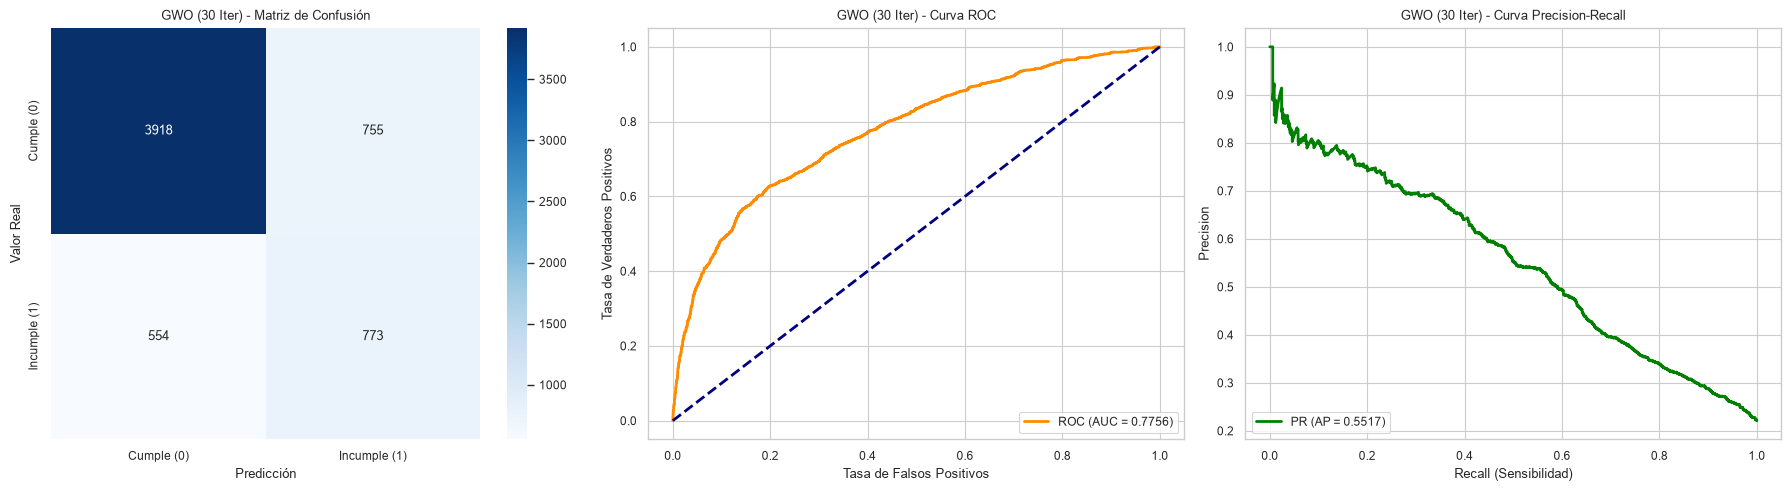

In [15]:
model_gwo_30 = xgb.XGBClassifier(
    **best_params_30, tree_method='hist', device='cuda',
    eval_metric='aucpr', random_state=GLOBAL_SEED, verbosity=0
)
model_gwo_30.fit(X_train, y_train, verbose=False)

y_pred_gwo_30 = model_gwo_30.predict(X_test)
y_prob_gwo_30 = model_gwo_30.predict_proba(X_test)[:, 1]
metrics_gwo_30 = evaluate_model(y_test, y_pred_gwo_30, y_prob_gwo_30, "GWO (30)")

plot_model_evaluation(y_test, y_pred_gwo_30, y_prob_gwo_30, "GWO (30 Iter)",
                      save_path=f"{OUTPUT_DIR}/eval_GWO_30.png")

# Optimización Híbrida GWO + MFO (8 + 7)

In [16]:
def run_hybrid(gwo_epochs, mfo_epochs, pop_size, seed, label=""):
    """Ejecuta la estrategia híbrida GWO→MFO con todas las verificaciones."""
    np.random.seed(seed)
    
    # FASE 1: GWO Global
    print(f"🐺 FASE 1: GWO ({gwo_epochs} épocas) - {label}")
    t0 = time.time()
    gwo = GWO.OriginalGWO(epoch=gwo_epochs, pop_size=pop_size)
    gwo_best = gwo.solve(problem_dict)
    t_gwo = time.time() - t0
    print(f"   Fitness GWO: {gwo_best.target.fitness:.4f} ({t_gwo:.1f}s)")
    
    # FASE 2: MFO Local
    best_gwo = gwo_best.solution
    margin = 0.20
    LB_loc = [max(lb, b - (ub - lb) * margin) for lb, ub, b in zip(LB, UB, best_gwo)]
    UB_loc = [min(ub, b + (ub - lb) * margin) for lb, ub, b in zip(LB, UB, best_gwo)]
    
    # P-17: Verificar que LB < UB
    for i, (l, u) in enumerate(zip(LB_loc, UB_loc)):
        if l >= u:
            print(f"⚠️ LB_loc[{i}]={l:.4f} >= UB_loc[{i}]={u:.4f}, ajustando.")
            mid = (l + u) / 2
            LB_loc[i] = mid - 0.01
            UB_loc[i] = mid + 0.01
    
    print(f"🦋 FASE 2: MFO ({mfo_epochs} épocas) - {label}")
    print(f"   LB_local: {np.round(LB_loc, 4)}")
    print(f"   UB_local: {np.round(UB_loc, 4)}")
    
    prob_local = {
        "obj_func": make_objective(seed),
        "bounds": FloatVar(lb=LB_loc, ub=UB_loc, name="xgb_local"),
        "minmax": "min",
    }
    
    np.random.seed(seed + 1)  # Semilla diferente para MFO
    t0 = time.time()
    mfo = MFO.OriginalMFO(epoch=mfo_epochs, pop_size=pop_size)
    mfo_best = mfo.solve(prob_local)
    t_mfo = time.time() - t0
    print(f"   Fitness MFO: {mfo_best.target.fitness:.4f} ({t_mfo:.1f}s)")
    
    ofe_total = (gwo_epochs + mfo_epochs) * pop_size * 3
    print(f"   OFEs totales: ({gwo_epochs}+{mfo_epochs}) × {pop_size} × 3 = {ofe_total}")
    
    return extract_params(mfo_best.solution), t_gwo + t_mfo, ofe_total

# Híbrido 8+7
best_params_hybrid_8_7, t_hyb8_7, ofe_hyb8_7 = run_hybrid(
    gwo_epochs=8, mfo_epochs=7, pop_size=20, 
    seed=GLOBAL_SEED, label="Híbrido (8+7)"
)
print(f"Mejores hiperparámetros Híbrido (8+7): {best_params_hybrid_8_7}")

2026/07/24 10:06:50 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=8, pop_size=20)


🐺 FASE 1: GWO (8 épocas) - Híbrido (8+7)


2026/07/24 10:07:34 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.4454920050720412, Global best: 0.4454920050720412, Runtime: 19.49389 seconds
2026/07/24 10:07:54 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4454920050720412, Global best: 0.4454920050720412, Runtime: 19.40989 seconds
2026/07/24 10:08:09 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4454920050720412, Global best: 0.4454920050720412, Runtime: 15.48935 seconds
2026/07/24 10:08:25 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4454920050720412, Global best: 0.4454920050720412, Runtime: 15.91671 seconds
2026/07/24 10:08:42 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4454920050720412, Global best: 0.4454920050720412, Runtime: 16.55993 seconds
2026/07/24 10:09:01 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P,

   Fitness GWO: 0.4455 (171.3s)
🦋 FASE 2: MFO (7 épocas) - Híbrido (8+7)
   LB_local: [1.426332e+02 3.316200e+00 2.820000e-02 6.000000e-01 6.000000e-01
 2.271500e+00]
   UB_local: [3.426332e+02 6.116200e+00 8.420000e-02 6.939000e-01 7.031000e-01
 3.471500e+00]


2026/07/24 10:10:15 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 1, Current best: 0.4450549570898878, Global best: 0.4450549570898878, Runtime: 16.42786 seconds
2026/07/24 10:10:32 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 2, Current best: 0.44488165279517755, Global best: 0.44488165279517755, Runtime: 17.32916 seconds
2026/07/24 10:10:50 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 3, Current best: 0.44488165279517755, Global best: 0.44488165279517755, Runtime: 17.67107 seconds
2026/07/24 10:11:04 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 4, Current best: 0.44461649297252054, Global best: 0.44461649297252054, Runtime: 14.14381 seconds
2026/07/24 10:11:18 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 5, Current best: 0.4441993739659294, Global best: 0.4441993739659294, Runtime: 14.11877 seconds
2026/07/24 10:11:33 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Probl

   Fitness MFO: 0.4442 (126.3s)
   OFEs totales: (8+7) × 20 × 3 = 900
Mejores hiperparámetros Híbrido (8+7): {'n_estimators': 235, 'max_depth': 5, 'learning_rate': 0.08154658938101847, 'subsample': 0.642537447269251, 'colsample_bytree': 0.6848817166036545, 'scale_pos_weight': 2.82919666172234}


# Entrenamiento Final Híbrido (8+7)

--- Híbrido (8+7) ---
PR-AUC: 0.5393 | ROC-AUC: 0.7707 | F1: 0.5378 | Recall: 0.5705 | Acc: 0.7832
TP=757 | FP=731 | TN=3942 | FN=570
💾 Figura guardada: resultados_gwo_mfo/eval_HYB_8_7.png


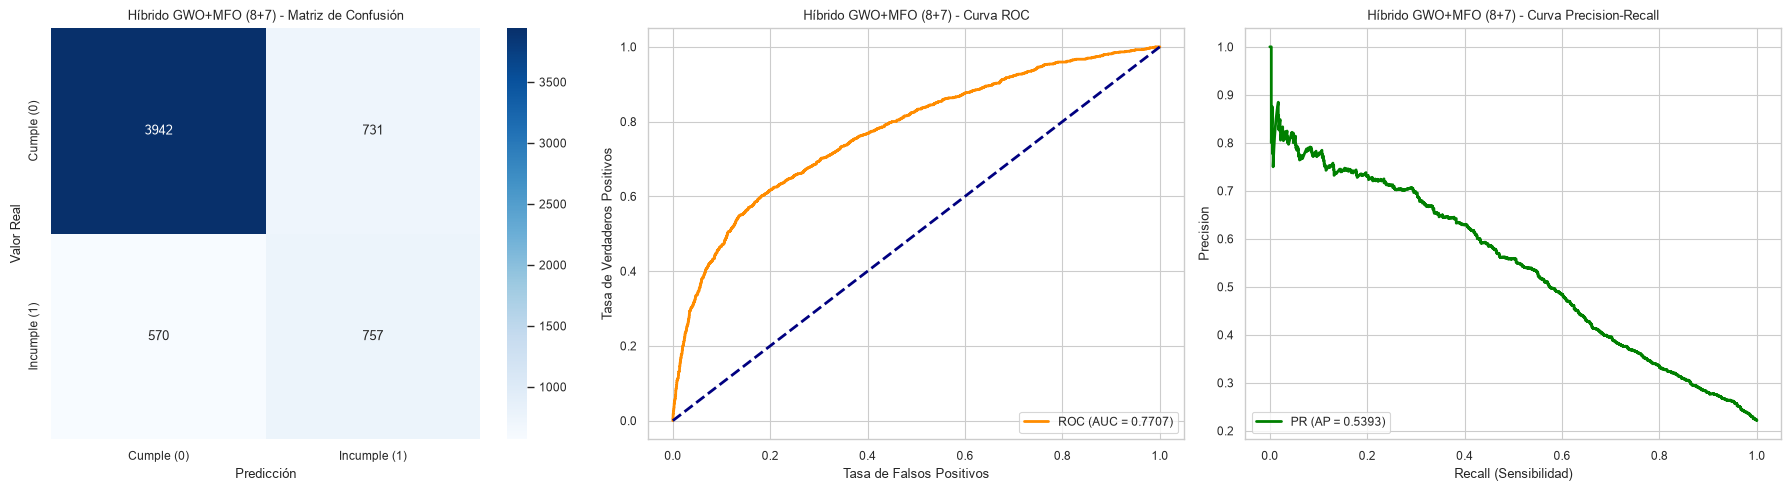

In [17]:
model_hybrid_8_7 = xgb.XGBClassifier(
    **best_params_hybrid_8_7, tree_method='hist', device='cuda',
    eval_metric='aucpr', random_state=GLOBAL_SEED, verbosity=0
)
model_hybrid_8_7.fit(X_train, y_train, verbose=False)

y_pred_hybrid_8_7 = model_hybrid_8_7.predict(X_test)
y_prob_hybrid_8_7 = model_hybrid_8_7.predict_proba(X_test)[:, 1]
metrics_hybrid_8_7 = evaluate_model(
    y_test, y_pred_hybrid_8_7, y_prob_hybrid_8_7, "Híbrido (8+7)"
)

plot_model_evaluation(y_test, y_pred_hybrid_8_7, y_prob_hybrid_8_7, 
                      "Híbrido GWO+MFO (8+7)",
                      save_path=f"{OUTPUT_DIR}/eval_HYB_8_7.png")

# Optimización Híbrida GWO + MFO (21 + 9)

In [18]:
best_params_hybrid_21_9, t_hyb21_9, ofe_hyb21_9 = run_hybrid(
    gwo_epochs=21, mfo_epochs=9, pop_size=20,
    seed=GLOBAL_SEED, label="Híbrido (21+9)"
)
print(f"Mejores hiperparámetros Híbrido (21+9): {best_params_hybrid_21_9}")

2026/07/24 10:11:49 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=21, pop_size=20)


🐺 FASE 1: GWO (21 épocas) - Híbrido (21+9)


2026/07/24 10:12:29 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.4498689029747898, Global best: 0.4498689029747898, Runtime: 18.81196 seconds
2026/07/24 10:12:49 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.446547447157406, Global best: 0.446547447157406, Runtime: 20.47675 seconds
2026/07/24 10:13:13 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.446547447157406, Global best: 0.446547447157406, Runtime: 23.92843 seconds
2026/07/24 10:13:36 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.446547447157406, Global best: 0.446547447157406, Runtime: 22.61301 seconds
2026/07/24 10:14:01 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.446547447157406, Global best: 0.446547447157406, Runtime: 25.58556 seconds
2026/07/24 10:14:19 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 

   Fitness GWO: 0.4450 (396.1s)
🦋 FASE 2: MFO (9 épocas) - Híbrido (21+9)
   LB_local: [1.627627e+02 4.060500e+00 4.000000e-02 6.792000e-01 8.850000e-01
 2.480900e+00]
   UB_local: [3.627627e+02 6.860500e+00 9.600000e-02 8.392000e-01 1.000000e+00
 3.680900e+00]


2026/07/24 10:18:55 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 1, Current best: 0.4451649517851122, Global best: 0.4451649517851122, Runtime: 15.11338 seconds
2026/07/24 10:19:11 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 2, Current best: 0.4451649517851122, Global best: 0.4451649517851122, Runtime: 16.09810 seconds
2026/07/24 10:19:27 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 3, Current best: 0.4451649517851122, Global best: 0.4451649517851122, Runtime: 15.85470 seconds
2026/07/24 10:19:44 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 4, Current best: 0.4451649517851122, Global best: 0.4451649517851122, Runtime: 17.28118 seconds
2026/07/24 10:20:01 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P, Epoch: 5, Current best: 0.4451649517851122, Global best: 0.4451649517851122, Runtime: 16.15537 seconds
2026/07/24 10:20:15 PM, INFO, mealpy.swarm_based.MFO.OriginalMFO: >>>Problem: P,

   Fitness MFO: 0.4452 (156.9s)
   OFEs totales: (21+9) × 20 × 3 = 1800
Mejores hiperparámetros Híbrido (21+9): {'n_estimators': 337, 'max_depth': 6, 'learning_rate': 0.08569574843411601, 'subsample': 0.7645591588404734, 'colsample_bytree': 0.9445558022022974, 'scale_pos_weight': 2.85346211987274}


# Entrenamiento Final Híbrido (21+9)

--- Híbrido (21+9) ---
PR-AUC: 0.5346 | ROC-AUC: 0.7647 | F1: 0.5220 | Recall: 0.5365 | Acc: 0.7827
TP=712 | FP=689 | TN=3984 | FN=615
💾 Figura guardada: resultados_gwo_mfo/eval_HYB_21_9.png


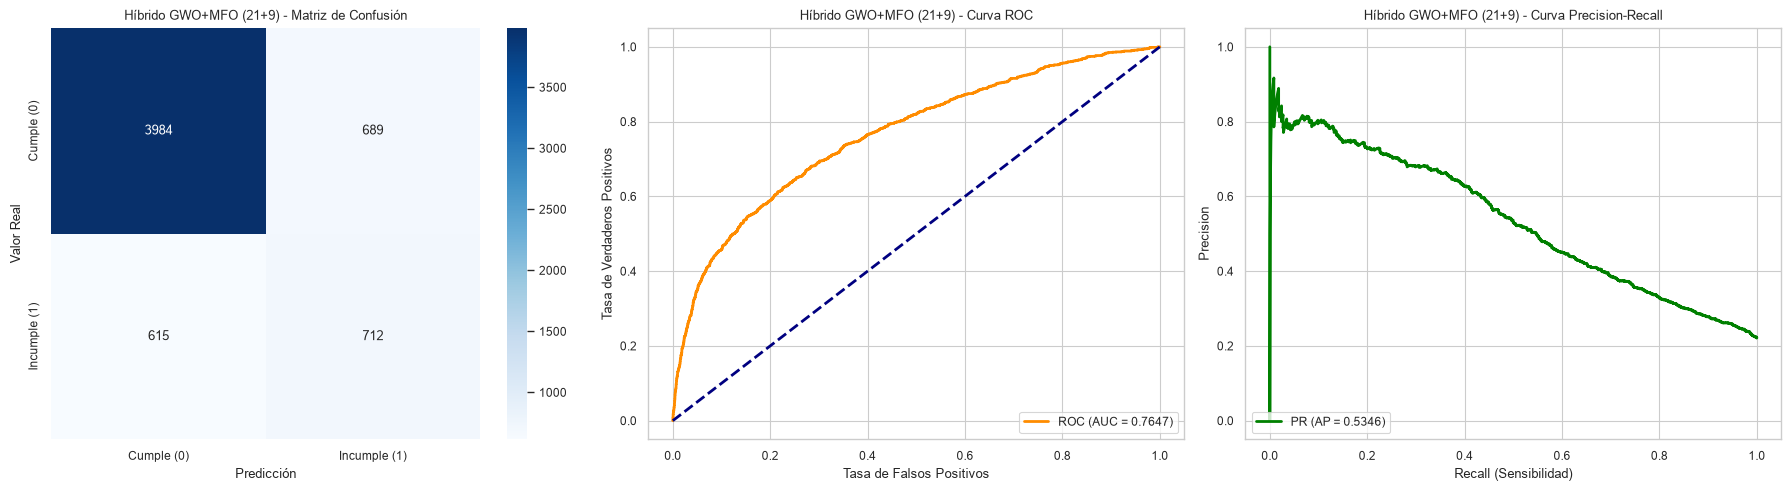

In [19]:
model_hybrid_21_9 = xgb.XGBClassifier(
    **best_params_hybrid_21_9, tree_method='hist', device='cuda',
    eval_metric='aucpr', random_state=GLOBAL_SEED, verbosity=0
)
model_hybrid_21_9.fit(X_train, y_train, verbose=False)

y_pred_hybrid_21_9 = model_hybrid_21_9.predict(X_test)
y_prob_hybrid_21_9 = model_hybrid_21_9.predict_proba(X_test)[:, 1]
metrics_hybrid_21_9 = evaluate_model(
    y_test, y_pred_hybrid_21_9, y_prob_hybrid_21_9, "Híbrido (21+9)"
)

plot_model_evaluation(y_test, y_pred_hybrid_21_9, y_prob_hybrid_21_9,
                      "Híbrido GWO+MFO (21+9)",
                      save_path=f"{OUTPUT_DIR}/eval_HYB_21_9.png")

# Tabla Comparativa de Rendimiento

In [20]:
all_metrics = {
    "XGBoost Base": metrics_base,
    "GWO (15 Iter)": metrics_gwo_15,
    "GWO (30 Iter)": metrics_gwo_30,
    "Híbrido (8+7)": metrics_hybrid_8_7,
    "Híbrido (21+9)": metrics_hybrid_21_9,
}

comparison_df = pd.DataFrame(all_metrics).T
comparison_df["Geo-Mean"] = np.sqrt(comparison_df["pr_auc"] * comparison_df["f1"])
comparison_df["Δ PR-AUC (%)"] = ((comparison_df["pr_auc"] / metrics_base["pr_auc"]) - 1) * 100

print("\n📊 TABLA COMPARATIVA")
print(comparison_df[["pr_auc","f1","recall","accuracy","Geo-Mean","Δ PR-AUC (%)"]].to_string())

# P-23: Exportar para el artículo
comparison_df.to_csv(f"{OUTPUT_DIR}/tabla_comparativa.csv")
print(f"\n💾 Tabla exportada: {OUTPUT_DIR}/tabla_comparativa.csv")


📊 TABLA COMPARATIVA
                  pr_auc        f1    recall  accuracy  Geo-Mean  Δ PR-AUC (%)
XGBoost Base    0.545869  0.530654  0.587038  0.770333  0.538208      0.000000
GWO (15 Iter)   0.546663  0.528275  0.566692  0.776167  0.537390      0.145408
GWO (30 Iter)   0.551702  0.541506  0.582517  0.781833  0.546580      1.068463
Híbrido (8+7)   0.539276  0.537833  0.570460  0.783167  0.538554     -1.207873
Híbrido (21+9)  0.534604  0.521994  0.536549  0.782667  0.528262     -2.063677

💾 Tabla exportada: resultados_gwo_mfo/tabla_comparativa.csv


# Análisis de Robustez Estadística (10 ejecuciones)

In [22]:
seeds = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021]

results = {
    "base": [], "gwo_15": [], "gwo_30": [], 
    "hybrid_8_7": [], "hybrid_21_9": []
}

print(f"Iniciando análisis de robustez ({len(seeds)} ejecuciones)...")
t_robust_start = time.time()

for i, seed in enumerate(seeds):
    print(f"\n{'='*60}")
    print(f"Ejecución {i+1}/{len(seeds)} (Seed: {seed})")
    print(f"{'='*60}")
    
    # --- Modelo Base ---
    mb = xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=base_scale_pos_weight,
        tree_method='hist', device='cuda', eval_metric='aucpr',
        random_state=seed, verbosity=0
    )
    mb.fit(X_train, y_train, verbose=False)
    results["base"].append(
        average_precision_score(y_test, mb.predict_proba(X_test)[:, 1])
    )
    
    # --- GWO 15 ---
    np.random.seed(seed)
    obj_seed = make_objective(seed)
    prob_15 = {"obj_func": obj_seed, 
               "bounds": FloatVar(lb=LB, ub=UB, name="x"), "minmax": "min"}
    g15 = GWO.OriginalGWO(epoch=15, pop_size=20)
    best_g15 = g15.solve(prob_15)
    bp_g15 = extract_params(best_g15.solution)
    bp_g15.update({"tree_method": 'hist', "device": 'cuda', 
                   "eval_metric": 'aucpr', "random_state": seed, "verbosity": 0})
    m_g15 = xgb.XGBClassifier(**bp_g15)
    m_g15.fit(X_train, y_train, verbose=False)  # P-10: verbose=False
    results["gwo_15"].append(
        average_precision_score(y_test, m_g15.predict_proba(X_test)[:, 1])
    )
    
    # --- GWO 30 ---
    np.random.seed(seed)
    g30 = GWO.OriginalGWO(epoch=30, pop_size=20)
    best_g30 = g30.solve(prob_15)
    bp_g30 = extract_params(best_g30.solution)
    bp_g30.update({"tree_method": 'hist', "device": 'cuda',
                   "eval_metric": 'aucpr', "random_state": seed, "verbosity": 0})
    m_g30 = xgb.XGBClassifier(**bp_g30)
    m_g30.fit(X_train, y_train, verbose=False)
    results["gwo_30"].append(
        average_precision_score(y_test, m_g30.predict_proba(X_test)[:, 1])
    )
    
    # --- Híbrido 8+7 ---
    best_sol_8_7 = best_g15.solution
    LB_l = [max(lb, b - (ub-lb)*0.20) for lb, ub, b in zip(LB, UB, best_sol_8_7)]
    UB_l = [min(ub, b + (ub-lb)*0.20) for lb, ub, b in zip(LB, UB, best_sol_8_7)]
    for j, (l, u) in enumerate(zip(LB_l, UB_l)):
        if l >= u:
            mid = (l + u) / 2; LB_l[j] = mid - 0.01; UB_l[j] = mid + 0.01
    prob_mfo_8_7 = {"obj_func": obj_seed,
                   "bounds": FloatVar(lb=LB_l, ub=UB_l, name="x"), "minmax": "min"}
    np.random.seed(seed + 1)
    mfo_8_7 = MFO.OriginalMFO(epoch=7, pop_size=20)
    best_m8_7 = mfo_8_7.solve(prob_mfo_8_7)
    bp_m8_7 = extract_params(best_m8_7.solution)
    bp_m8_7.update({"tree_method": 'hist', "device": 'cuda',
                   "eval_metric": 'aucpr', "random_state": seed, "verbosity": 0})
    m_m8_7 = xgb.XGBClassifier(**bp_m8_7)
    m_m8_7.fit(X_train, y_train, verbose=False)
    results["hybrid_8_7"].append(
        average_precision_score(y_test, m_m8_7.predict_proba(X_test)[:, 1])
    )
    
    # --- Híbrido 21+9 ---
    best_sol_21_9 = best_g30.solution
    LB_l21_9 = [max(lb, b - (ub-lb)*0.20) for lb, ub, b in zip(LB, UB, best_sol_21_9)]
    UB_l21_9 = [min(ub, b + (ub-lb)*0.20) for lb, ub, b in zip(LB, UB, best_sol_21_9)]
    for j, (l, u) in enumerate(zip(LB_l21_9, UB_l21_9)):
        if l >= u:
            mid = (l + u) / 2; LB_l21_9[j] = mid - 0.01; UB_l21_9[j] = mid + 0.01
    prob_mfo_21_9 = {"obj_func": obj_seed,
                   "bounds": FloatVar(lb=LB_l21_9, ub=UB_l21_9, name="x"), "minmax": "min"}
    np.random.seed(seed + 1)
    mfo_21_9 = MFO.OriginalMFO(epoch=9, pop_size=20)
    best_m21_9 = mfo_21_9.solve(prob_mfo_21_9)
    bp_m21_9 = extract_params(best_m21_9.solution)
    bp_m21_9.update({"tree_method": 'hist', "device": 'cuda',
                   "eval_metric": 'aucpr', "random_state": seed, "verbosity": 0})
    m_m21_9 = xgb.XGBClassifier(**bp_m21_9)
    m_m21_9.fit(X_train, y_train, verbose=False)
    results["hybrid_21_9"].append(
        average_precision_score(y_test, m_m21_9.predict_proba(X_test)[:, 1])
    )
    
    # P-11: Checkpoint cada 5 ejecuciones
    if (i + 1) % 5 == 0:
        with open(f"{OUTPUT_DIR}/robustness_checkpoint.json", "w") as f:
            json.dump({"seeds": seeds[:i+1], "results": results}, f, indent=2)
        print(f"💾 Checkpoint guardado (ejecución {i+1})")

t_robust_total = time.time() - t_robust_start
print(f"\n✅ Análisis de robustez completado en {t_robust_total/3600:.2f} horas")

# Guardado final
with open(f"{OUTPUT_DIR}/robustness_results.json", "w") as f:
    json.dump({"seeds": seeds, "results": results, 
               "total_time_hours": t_robust_total/3600}, f, indent=2)
print(f"💾 Resultados guardados: {OUTPUT_DIR}/robustness_results.json")

Iniciando análisis de robustez (10 ejecuciones)...

Ejecución 1/10 (Seed: 42)


2026/07/24 10:33:47 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=15, pop_size=20)
2026/07/24 10:34:22 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44790638679390254, Global best: 0.44790638679390254, Runtime: 14.39698 seconds
2026/07/24 10:34:36 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44790638679390254, Global best: 0.44790638679390254, Runtime: 13.71001 seconds
2026/07/24 10:34:52 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44790638679390254, Global best: 0.44790638679390254, Runtime: 16.24071 seconds
2026/07/24 10:35:10 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.44790638679390254, Global best: 0.44790638679390254, Runtime: 17.84378 seconds
2026/07/24 10:35:26 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44790638679390254, Global best: 0.44790638679390


Ejecución 2/10 (Seed: 123)


2026/07/24 10:56:19 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=15, pop_size=20)
2026/07/24 10:57:08 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.450474821758912, Global best: 0.450474821758912, Runtime: 26.85802 seconds
2026/07/24 10:57:29 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4498363999869725, Global best: 0.4498363999869725, Runtime: 21.43031 seconds
2026/07/24 10:57:51 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4493871020630158, Global best: 0.4493871020630158, Runtime: 21.63955 seconds
2026/07/24 10:58:14 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4493871020630158, Global best: 0.4493871020630158, Runtime: 23.34381 seconds
2026/07/24 10:58:30 PM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4493871020630158, Global best: 0.4493871020630158, Runtime


Ejecución 3/10 (Seed: 456)


...


Ejecución 9/10 (Seed: 1819)


2026/07/25 01:10:31 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=15, pop_size=20)
2026/07/25 01:11:15 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44652891587492977, Global best: 0.44652891587492977, Runtime: 23.31907 seconds
2026/07/25 01:11:33 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.44652891587492977, Global best: 0.44652891587492977, Runtime: 18.18954 seconds
2026/07/25 01:11:51 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.44652891587492977, Global best: 0.44652891587492977, Runtime: 18.33702 seconds
2026/07/25 01:12:11 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.44652891587492977, Global best: 0.44652891587492977, Runtime: 19.66917 seconds
2026/07/25 01:12:32 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.44652891587492977, Global best: 0.44652891587492


Ejecución 10/10 (Seed: 2021)


2026/07/25 01:33:34 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: OriginalGWO(epoch=15, pop_size=20)
2026/07/25 01:34:08 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 1, Current best: 0.44905076648719233, Global best: 0.44905076648719233, Runtime: 14.50390 seconds
2026/07/25 01:34:22 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 2, Current best: 0.4480254481948219, Global best: 0.4480254481948219, Runtime: 14.80680 seconds
2026/07/25 01:34:37 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 3, Current best: 0.4480254481948219, Global best: 0.4480254481948219, Runtime: 14.78537 seconds
2026/07/25 01:34:52 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 4, Current best: 0.4480254481948219, Global best: 0.4480254481948219, Runtime: 14.92693 seconds
2026/07/25 01:35:06 AM, INFO, mealpy.swarm_based.GWO.OriginalGWO: >>>Problem: P, Epoch: 5, Current best: 0.4480254481948219, Global best: 0.4480254481948219, Run

💾 Checkpoint guardado (ejecución 10)

✅ Análisis de robustez completado en 3.25 horas
💾 Resultados guardados: resultados_gwo_mfo/robustness_results.json


# Análisis Estadístico Completo (IC 95% + Wilcoxon + Holm-Bonferroni)

In [23]:
# ============================================================
# INTERVALOS DE CONFIANZA 95%
# ============================================================
def ci_95(data):
    n = len(data)
    m = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    t_crit = t_dist.ppf(0.975, df=n-1)
    return m, m - t_crit * se, m + t_crit * se

print("\n📊 INTERVALOS DE CONFIANZA (95%)")
print(f"{'Modelo':25s} {'Media':>8s} {'IC_inf':>8s} {'IC_sup':>8s} {'Var':>12s}")
print("-" * 65)
for name, key in [("XGBoost Base", "base"), ("GWO (15)", "gwo_15"),
                   ("GWO (30)", "gwo_30"), ("Híbrido (8+7)", "hybrid_8_7"),
                   ("Híbrido (21+9)", "hybrid_21_9")]:
    data = results[key]
    m, lo, hi = ci_95(data)
    v = np.var(data, ddof=1)
    print(f"{name:25s} {m:8.4f} {lo:8.4f} {hi:8.4f} {v:12.2e}")

# ============================================================
# SHAPIRO-WILK (justificación de test no paramétrico)
# ============================================================
print("\n📊 SHAPIRO-WILK (normalidad)")
for name, key in [("Base", "base"), ("GWO-15", "gwo_15"), 
                   ("GWO-30", "gwo_30"), ("Híb-8+7", "hybrid_8_7"),
                   ("Híb-21+9", "hybrid_21_9")]:
    stat_sw, p_sw = shapiro(results[key])
    normal = "Normal" if p_sw > 0.05 else "No normal"
    print(f"  {name:15s}: W={stat_sw:.4f}, p={p_sw:.4f} → {normal}")

# ============================================================
# WILCOXON + HOLM-BONFERRONI + EFFECT SIZE
# ============================================================
comparisons = [
    ("Híb(8+7) vs Base",       "hybrid_8_7", "base"),
    ("Híb(21+9) vs Base",       "hybrid_21_9", "base"),
    ("Híb(8+7) vs GWO(15)",    "hybrid_8_7", "gwo_15"),
    ("Híb(21+9) vs GWO(30)",    "hybrid_21_9", "gwo_30"),
    ("Híb(21+9) vs Híb(8+7)", "hybrid_21_9", "hybrid_8_7"),
]

n_comp = len(comparisons)
n = len(seeds)
max_W = n * (n + 1) / 2  # = 120

wilcoxon_results = []
for name, key_a, key_b in comparisons:
    W, p = wilcoxon(results[key_a], results[key_b], alternative='greater')
    r_rb = 1 - (2 * W) / max_W
    wilcoxon_results.append((name, W, p, r_rb))

# Holm-Bonferroni: ordenar por p-value
wilcoxon_results.sort(key=lambda x: x[2])

print(f"\n{'='*90}")
print("WILCOXON + HOLM-BONFERRONI + EFFECT SIZE")
print(f"{'='*90}")
print(f"{'Comparación':35s} {'W':>5s} {'p':>10s} {'p_Holm':>10s} {'r_rb':>7s} {'Sig?':>5s}")
print("-" * 90)

for rank, (name, W, p, r_rb) in enumerate(wilcoxon_results):
    p_holm = min(p * (n_comp - rank), 1.0)
    sig = "✅" if p_holm < 0.05 else "❌"
    print(f"{name:35s} {W:5.0f} {p:10.6f} {p_holm:10.6f} {r_rb:7.3f} {sig:>5s}")

# Potencia estadística con n=15
print(f"\n📊 Potencia estadística: n={n}, p_min posible = {1/2**n:.6f}")
print(f"   Con α=0.05 y n=15, se necesita W≥115 para significancia unilateral.")


📊 INTERVALOS DE CONFIANZA (95%)
Modelo                       Media   IC_inf   IC_sup          Var
-----------------------------------------------------------------
XGBoost Base                0.5448   0.5424   0.5473     1.19e-05
GWO (15)                    0.5501   0.5459   0.5544     3.55e-05
GWO (30)                    0.5514   0.5480   0.5547     2.19e-05
Híbrido (8+7)               0.5511   0.5487   0.5535     1.14e-05
Híbrido (21+9)              0.5525   0.5499   0.5551     1.34e-05

📊 SHAPIRO-WILK (normalidad)
  Base           : W=0.9084, p=0.2701 → Normal
  GWO-15         : W=0.8193, p=0.0248 → No normal
  GWO-30         : W=0.7997, p=0.0144 → No normal
  Híb-8+7        : W=0.8931, p=0.1838 → Normal
  Híb-21+9       : W=0.9338, p=0.4860 → Normal

WILCOXON + HOLM-BONFERRONI + EFFECT SIZE
Comparación                             W          p     p_Holm    r_rb  Sig?
------------------------------------------------------------------------------------------
Híb(21+9) vs Base       

# Boxplots PR-AUC

💾 Boxplot guardado: resultados_gwo_mfo/Boxplot_PR-AUC_15_Ejecuciones.png


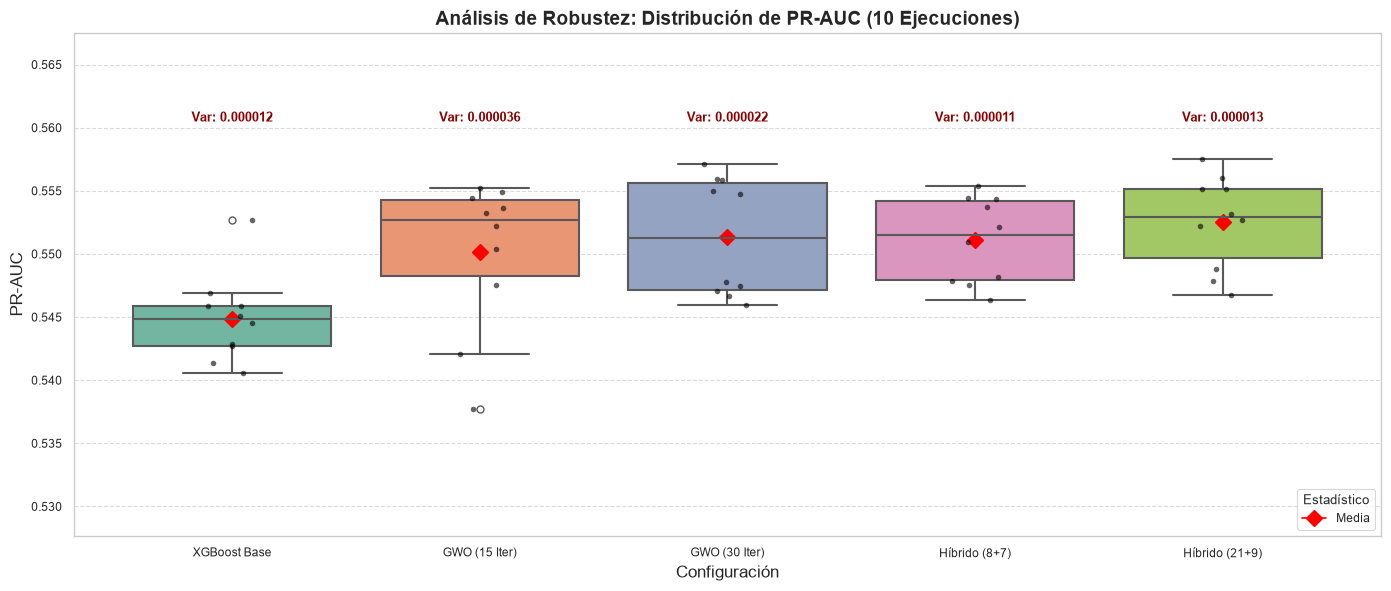

In [24]:
plt.figure(figsize=(14, 6))

df_robust = pd.DataFrame({
    "XGBoost Base": results["base"],
    "GWO (15 Iter)": results["gwo_15"],
    "GWO (30 Iter)": results["gwo_30"],
    "Híbrido (8+7)": results["hybrid_8_7"],
    "Híbrido (21+9)": results["hybrid_21_9"]
}).melt(var_name="Modelo", value_name="PR-AUC")

ax = sns.boxplot(data=df_robust, x="Modelo", y="PR-AUC", palette="Set2",
                 linewidth=1.5, fliersize=5)
sns.stripplot(data=df_robust, x="Modelo", y="PR-AUC", color="black",
              size=4, alpha=0.6, jitter=True)

models_list = df_robust["Modelo"].unique()
means_list = [df_robust[df_robust["Modelo"] == m]["PR-AUC"].mean() for m in models_list]
vars_list = [df_robust[df_robust["Modelo"] == m]["PR-AUC"].var() for m in models_list]

for i, (model, mean) in enumerate(zip(models_list, means_list)):
    ax.plot(i, mean, marker='D', color='red', markersize=8,
            label='Media' if i == 0 else "")

plt.title("Análisis de Robustez: Distribución de PR-AUC (10 Ejecuciones)",
          fontsize=14, fontweight='bold')
plt.ylabel("PR-AUC", fontsize=12)
plt.xlabel("Configuración", fontsize=12)
plt.ylim(min(df_robust["PR-AUC"]) - 0.01, max(df_robust["PR-AUC"]) + 0.01)
plt.legend(title="Estadístico", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, (model, var, mean_val) in enumerate(zip(models_list, vars_list, means_list)):
    var_text = f'Var: {var:.2e}' if var < 0.00001 else f'Var: {var:.6f}'
    ax.annotate(var_text, xy=(i, mean_val), 
                xytext=(i, max(df_robust["PR-AUC"]) + 0.003),
                ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/Boxplot_PR-AUC_15_Ejecuciones.png", 
            dpi=300, bbox_inches='tight')
print(f"💾 Boxplot guardado: {OUTPUT_DIR}/Boxplot_PR-AUC_15_Ejecuciones.png")
plt.show()

# Resumen de Tiempos y OFEs

In [25]:
print("\n📊 RESUMEN DE TIEMPOS Y OFEs")
print(f"{'Método':25s} {'Tiempo (s)':>12s} {'OFEs':>8s}")
print("-" * 50)
print(f"{'GWO (15 iter)':25s} {t_gwo15:12.1f} {15*20*3:8d}")
print(f"{'GWO (30 iter)':25s} {t_gwo30:12.1f} {30*20*3:8d}")
print(f"{'Híbrido (8+7)':25s} {t_hyb8_7:12.1f} {ofe_hyb8_7:8d}")
print(f"{'Híbrido (21+9)':25s} {t_hyb21_9:12.1f} {ofe_hyb21_9:8d}")
print(f"{'Robustez (total)':25s} {t_robust_total:12.1f} {'N/A':>8s}")


📊 RESUMEN DE TIEMPOS Y OFEs
Método                      Tiempo (s)     OFEs
--------------------------------------------------
GWO (15 iter)                    259.1      900
GWO (30 iter)                    710.9     1800
Híbrido (8+7)                    297.5      900
Híbrido (21+9)                   553.0     1800
Robustez (total)               11682.8      N/A
